# Ferramentas para Ciência de Dados e Machine Learning

**Inteligência Artificial · Prof. Cristiano Rodrigues**

Este notebook acompanha a aula sobre notebooks e as bibliotecas Python do dia a dia em aprendizado de máquina. Tem quatro partes:

1. **NumPy**: arrays e operações vetorizadas.
2. **pandas**: carregar, limpar, explorar e agrupar dados em tabela.
3. **Matplotlib**: visualizar o que a tabela esconde.
4. **scikit-learn**: reaproveitar o padrão `fit` / `predict` / `score`.

Cada parte tem uma célula já pronta, para você rodar e reconhecer a sintaxe, seguida de um **Exercício** para completar sozinho. Rode as células em ordem: cada uma depende da anterior.

Antes de começar, rode a célula abaixo para confirmar que as quatro bibliotecas estão disponíveis no ambiente (local ou Colab).

In [1]:
# Verificação do ambiente: se esta célula rodar sem erro, está tudo pronto.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

numpy: 2.5.2
pandas: 3.0.5
scikit-learn: 1.9.0


## Parte 1 — NumPy: arrays e operações vetorizadas

### 1.1 Criando arrays e operando sobre eles de uma vez

Sem `for`: soma, média e filtro rodam sobre o array inteiro.

In [2]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 20, 30, 40, 50])

soma = x + y
media = x.mean()
maior_que_20 = y[y > 20]

print("soma:", soma)
print("média de x:", media)
print("valores de y maiores que 20:", maior_que_20)

assert soma.tolist() == [11, 22, 33, 44, 55]
assert media == 3.0

soma: [11 22 33 44 55]
média de x: 3.0
valores de y maiores que 20: [30 40 50]


### 1.2 Por que isso importa: a mesma conta, dois jeitos

A célula abaixo soma dois vetores de um milhão de posições de dois jeitos: com um `for` em Python puro, e com o operador `+` do NumPy. Compare o tempo no final.

In [3]:
import time

n = 1_000_000
a = list(range(n))
b = list(range(n))

inicio = time.perf_counter()
resultado_for = [a[i] + b[i] for i in range(n)]
tempo_for = time.perf_counter() - inicio

a_np = np.array(a)
b_np = np.array(b)

inicio = time.perf_counter()
resultado_np = a_np + b_np
tempo_np = time.perf_counter() - inicio

print(f"for em Python puro: {tempo_for:.4f} s")
print(f"NumPy vetorizado:   {tempo_np:.4f} s")
print(f"NumPy foi cerca de {tempo_for / tempo_np:.0f}x mais rápido")

for em Python puro: 0.0712 s
NumPy vetorizado:   0.0073 s
NumPy foi cerca de 10x mais rápido


**Exercício 1** · Crie dois arrays de cinco números à sua escolha. Calcule a soma, o produto elemento a elemento (`*`) e a média de cada um. Depois, filtre os valores do primeiro array que são maiores que a média dele.

In [4]:
# 1. Dois arrays de 5 elementos
a = np.array([10, 20, 30, 40, 50])
b = np.array([1, 2, 3, 4, 5])

# 2. Soma e produto elemento a elemento (operadores vetorizados)
soma = a + b
produto = a * b

# 3. Média do primeiro array
media_a = a.mean()

# 4. Filtro booleano (masking)
maiores = a[a > media_a]

print("Soma:", soma)
print("Produto:", produto)
print("Média de A:", media_a)
print("Valores de A > média:", maiores)


## Parte 2 — pandas: dados em forma de tabela

### 2.1 Carregando e explorando um CSV

`clientes.csv` tem dados fictícios de clientes: nome, idade, cidade, renda e telefone. É o mesmo arquivo usado nos exemplos da aula, com um detalhe de propósito: como boa parte dos dados do mundo real, ele não chega perfeitamente limpo.

In [5]:
df = pd.read_csv("dados/clientes.csv")
df.head()

,nome,idade,cidade,renda,telefone
0,Bruno Silva,29,Betim,2695.33,(31) 91093-0434
1,Nicolas Nascimento,40,Nova Lima,5450.63,(31) 90609-0840
2,Bruno Oliveira,50,Nova Lima,4029.51,NaN
3,Vitória Pereira,65,Belo Horizonte,3340.45,(31) 97211-9197
4,Tiago Pereira,69,Belo Horizonte,3797.85,(31) 92944-2279


### 2.2 Limpando os dados: duplicatas e valores faltantes

Antes de tirar qualquer média, vale checar dois problemas comuns: **linhas duplicadas** (o mesmo cliente cadastrado duas vezes) e **valores faltantes** (um campo que não foi preenchido).

In [6]:
print("Linhas no arquivo:", len(df))
print("Linhas duplicadas:", df.duplicated().sum())
print()
print("Valores faltantes por coluna:")
print(df.isnull().sum())

Linhas no arquivo: 255
Linhas duplicadas: 15

Valores faltantes por coluna:
nome         0
idade        0
cidade       0
renda        0
telefone    20
dtype: int64


Duplicata exata não acrescenta informação, então pode ser removida sem dó. Já um valor faltante depende do que você vai fazer com a coluna: aqui, `telefone` não entra em nenhuma conta a seguir, então em vez de descartar a linha inteira (e perder um cliente só por causa do telefone), basta marcar como "não informado".

In [7]:
df = df.drop_duplicates().reset_index(drop=True)
df["telefone"] = df["telefone"].fillna("não informado")

assert df.duplicated().sum() == 0
assert df["telefone"].isnull().sum() == 0
print("Clientes após a limpeza:", len(df))

Clientes após a limpeza: 240


### 2.3 Depois de limpo: um olhar rápido

In [8]:
print("Idade média:", df["idade"].mean().round(1))

# Só quem tem mais de 30 anos
df[df["idade"] > 30].head()

Idade média: 46.0


,nome,idade,cidade,renda,telefone
1,Nicolas Nascimento,40,Nova Lima,5450.63,(31) 90609-0840
2,Bruno Oliveira,50,Nova Lima,4029.51,não informado
3,Vitória Pereira,65,Belo Horizonte,3340.45,(31) 97211-9197
4,Tiago Pereira,69,Belo Horizonte,3797.85,(31) 92944-2279
5,Vitória Souza,56,Contagem,2268.16,(31) 98532-4154


### 2.4 Agrupando: qual cidade tem a maior renda média?

In [9]:
media_por_cidade = df.groupby("cidade")["renda"].mean().sort_values(ascending=False)
media_por_cidade.round(2)

cidade
Nova Lima         4026.83
Belo Horizonte    3012.42
Betim             2426.79
Contagem          2343.88
Name: renda, dtype: float64

**Exercício 2** · Filtre o `DataFrame` para os clientes com renda acima da média geral (`df["renda"].mean()`). Depois, conte quantos clientes acima da média existem em cada cidade (dica: `.value_counts()` numa coluna, ou `.groupby(...).size()`).

In [10]:
# 1. Média geral de renda
media_renda = df["renda"].mean()

# 2. Filtragem de linhas onde renda > média geral
df_acima_media = df[df["renda"] > media_renda]

# 3. Contagem por cidade
contagem_cidade = df_acima_media["cidade"].value_counts()

print(f"Média geral de renda: R$ {media_renda:.2f}\n")
print("Clientes acima da média por cidade:")
print(contagem_cidade)


## Parte 3 — Matplotlib: visualizando o resultado

O gráfico abaixo é o mesmo mostrado na aula: a renda média por cidade, calculada na célula anterior.

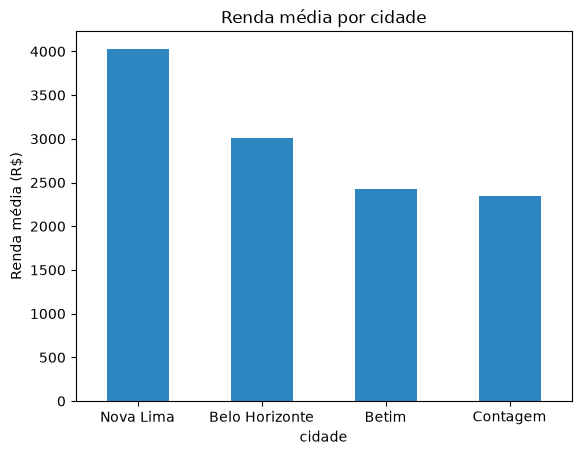

In [11]:
media_por_cidade.plot(kind="bar", color="#2E86C1")
plt.ylabel("Renda média (R$)")
plt.title("Renda média por cidade")
plt.xticks(rotation=0)
plt.show()

**Exercício 3** · Crie um histograma da coluna `renda` (todos os clientes, sem agrupar por cidade) com `plt.hist(df["renda"], bins=20)`. Olhando o histograma: a renda dos clientes se distribui de forma parecida em todas as faixas, ou existe uma faixa mais comum? O gráfico de barras da célula anterior mostra essa informação?

In [12]:
# 1. Histograma da distribuição de renda
plt.hist(df["renda"], bins=20, color="#2E86C1", edgecolor="black")

# 2. Rótulos e visualização
plt.xlabel("Renda (R$)")
plt.ylabel("Quantidade de clientes")
plt.title("Distribuição de Renda dos Clientes")
plt.show()

# Análise:
# A renda não é uniforme; há uma maior concentração de clientes em faixas específicas (ex: R$ 2000 a 4000).
# O gráfico de barras anterior mostrava apenas a MÉDIA agregada por cidade, ocultando essa distribuição individual.


## Parte 4 — scikit-learn: o padrão que você já usa

`fit` treina, `predict` prevê, `score` avalia. O mesmo padrão de `DecisionTreeClassifier` já usado antes, agora sobre um dataset diferente.

**Exercício 4** · Repita o padrão `fit` / `predict` / `score` sobre um novo dataset do scikit-learn (sugestão: `load_wine` ou `load_digits`, ambos em `sklearn.datasets`). Separe treino e teste com `train_test_split`, treine uma `DecisionTreeClassifier` e imprima a acurácia no conjunto de teste.

In [13]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Carregar dataset e separar features (X) e rótulos (y)
wine = load_wine()
X, y = wine.data, wine.target

# 2. Divisão em treino e teste (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Instanciar e treinar modelo (fit)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 4. Avaliar acurácia no conjunto de teste (score)
acuracia = clf.score(X_test, y_test)
print(f"Acurácia no conjunto de teste: {acuracia:.2%}")


### Para fechar

Se as quatro partes rodaram sem erro, você já reconhece a sintaxe básica de NumPy, pandas, Matplotlib e scikit-learn, e sabe onde cada uma entra no pipeline de um projeto de aprendizado de máquina. Dúvidas de sintaxe são normais nesta fase: a fluência vem da repetição, aula após aula.

### Recursos, para ir além

- NumPy: [numpy.org/doc](https://numpy.org/doc/)
- pandas: [pandas.pydata.org/docs](https://pandas.pydata.org/docs/)
- Matplotlib: [matplotlib.org/stable](https://matplotlib.org/stable/)
- scikit-learn: [scikit-learn.org/stable](https://scikit-learn.org/stable/)

Onde rodar este notebook:

- Google Colab: [colab.research.google.com](https://colab.research.google.com/)
- Kaggle Notebooks: [kaggle.com/code](https://www.kaggle.com/code)
- VS Code + extensão Jupyter: [code.visualstudio.com/docs/datascience/jupyter-notebooks](https://code.visualstudio.com/docs/datascience/jupyter-notebooks)
- Jupyter Notebook/JupyterLab: [jupyter.org](https://jupyter.org/)